Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
from evojax.util import get_params_format_fn

import time
import numpy as np
import pandas as pd
from scipy import io
import matplotlib.pyplot as plt

# choose GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
#jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

Problem: Navier-Stokes Equation

        u*u_x + v*u_y - 1/Re*(u_xx+u_yy) + p_x = 0
        v*v_x + v*v_y - 1/Re*(v_xx+v_yy) + p_y = 0
        u_x + v_y = 0

In [2]:
# parameter
Re = 20000

In [3]:
sim = pd.read_csv('LDC_RE20000_258x258_CELL.csv')
sim

,x,y,u,v,p
0,0.000000,0.0,0.0,0.0,0.000000e+00
1,0.001953,0.0,0.0,0.0,-3.689997e-08
2,0.005859,0.0,0.0,0.0,-2.400000e-07
3,0.009766,0.0,0.0,0.0,-5.874995e-07
4,0.013672,0.0,0.0,0.0,-9.540022e-07
...,...,...,...,...,...
66559,0.986328,1.0,1.0,0.0,2.425521e-01
66560,0.990234,1.0,1.0,0.0,3.106299e-01
66561,0.994141,1.0,1.0,0.0,4.146936e-01
66562,0.998047,1.0,1.0,0.0,6.042248e-01


In [4]:
sim_x = sim['x'].values.reshape(-1,1)
sim_y = sim['y'].values.reshape(-1,1)
sim_u = sim['u'].values.reshape(-1,1)
sim_v = sim['v'].values.reshape(-1,1)
sim_p = sim['p'].values.reshape(-1,1)
x_l, x_u, y_l, y_u = np.min(sim_x), np.max(sim_x), np.min(sim_y), np.max(sim_y)
ext = [x_l, x_u, y_l, y_u]
print (x_l, x_u, y_l, y_u)


0.0 1.0 0.0 1.0


In [5]:
data_X, data_Y = np.hstack([sim_x, sim_y]), np.hstack([sim_u, sim_v, sim_p])
print (data_X.shape, data_Y.shape)

(66564, 2) (66564, 3)


In [6]:
dx = dy = sim_x[2]-sim_x[1]
print (dx, dy)


[0.00390625] [0.00390625]


In [7]:
data_XX = data_X
data_YY = data_Y
# exclude corner points
corners = (sim['x'] == x_l) & (sim['y'] == y_u) | (sim['x'] == x_u) & (sim['y'] == y_u) | (sim['x'] == x_l) & (sim['y'] == y_l) | (sim['x'] == x_u) & (sim['y'] == y_l)
data_X, data_Y = data_X[~corners], data_Y[~corners]

# pressure ref
x_ref, y_ref = np.unique(sim_x), np.unique(sim_y)
x_ref, y_ref = np.take(x_ref, x_ref.size //2), np.take(y_ref, y_ref.size //2)
print (x_ref, y_ref)

# split into BC data
bc = (data_X[:,0] == x_l) | (data_X[:,0] == x_u) | (data_X[:,1] == y_l) | (data_X[:,1] == y_u)
data_X_BC, data_Y_BC = data_X[bc], data_Y[bc]
data_X,data_Y = data_X[~bc], data_Y[~bc]
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

0.501953125 0.501953125
(65536, 2) (65536, 3) (1024, 2) (1024, 3)


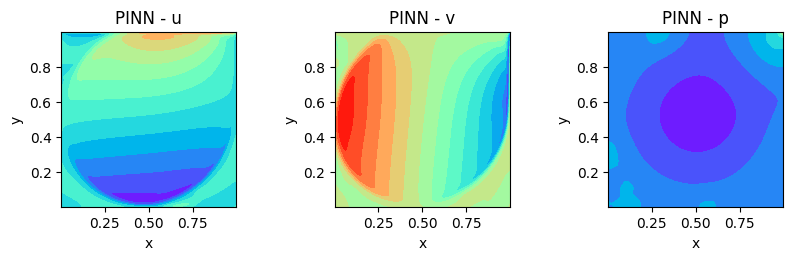

In [8]:
# plot
fig = plt.figure(figsize=(10, 5))
con_lv = 15
ax1 = fig.add_subplot(2,3,1,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,0], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y');plt.title('PINN - u');
ax1 = fig.add_subplot(2,3,2,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,1], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - v'); 
ax1 = fig.add_subplot(2,3,3,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,2], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - p');
plt.show()

In [9]:
# convert to jnp
data_X, data_Y, data_X_BC, data_Y_BC = jnp.array(data_X), jnp.array(data_Y), jnp.array(data_X_BC), jnp.array(data_Y_BC)
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

(65536, 2) (65536, 3) (1024, 2) (1024, 3)


DNN / PINN   

In [10]:
nn_acf = nn.silu
class PINN(nn.Module):
    """PINNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                    nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]     

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([x,y-1])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(jnp.pi*hidden)
            # hidden = jnp.sin(hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            return (u, v, p)  
    
        u, v, p = get_uvp(x, y)

        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE = get_uvp(xE, y)
        uW, vW, pW = get_uvp(xW, y)
        uN, vN, pN = get_uvp(x, yN)
        uS, vS, pS = get_uvp(x, yS)
        ue, ve, pe = get_uvp(xe, y)
        uw, vw, pw = get_uvp(xw, y)
        un, vn, pn = get_uvp(x, yn)
        us, vs, ps = get_uvp(x, ys)

        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 1, 0
        uSbc, vSbc = 0, 0   

        # points on Boundary
        xB_E, xB_W = (xE > x_u), (xW < x_l)
        yB_N, yB_S = (yN > y_u), (yS < y_l)
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 1, 0
        uSbc, vSbc = 0, 0
        
        uE, vE = jnp.where(xB_E, 2*uEbc-u, uE), jnp.where(xB_E, 2*vEbc-v, vE)
        uW, vW = jnp.where(xB_W, 2*uWbc-u, uW), jnp.where(xB_W, 2*vWbc-v, vW)
        uN, vN = jnp.where(yB_N, 2*uNbc-u, uN), jnp.where(yB_N, 2*vNbc-v, vN)
        uS, vS = jnp.where(yB_S, 2*uSbc-u, uS), jnp.where(yB_S, 2*vSbc-v, vS)         

    
        xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
        yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uE, vE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE)
        uW, vW = jnp.where(xB_W, uWbc, uW), jnp.where(xB_W, vWbc, vW)
        uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
        uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)

        
        xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
        yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        ue, ve = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve)
        uw, vw = jnp.where(xB_w, uWbc, uw), jnp.where(xB_w, vWbc, vw)
        un, vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
        us, vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)

        ae = ue
        aw = -uw
        an = vn
        aas = -vs
        
        source_x = (pe - pw)
        source_y = (pn - ps) 

        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)
        nbc = (~bc)
        
        div = (uE - uW + vN - vS)/2

        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx*Re) #-u*div
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx*Re) #-v*div

        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx
        
        residuals_continuity = div/dx
        residuals_momentum_1 = mom_x/dx
        residuals_momentum_2 = mom_y/dy 
        res_c = (ue - uw + vn - vs)/dx
        res_p = pE + pW + pN + pS
        
        outputs = jnp.hstack([u, v, p, residuals_continuity, residuals_momentum_1, residuals_momentum_2, bc, nbc,res_u,res_v,res_c,res_p])
        return outputs        
    
class DNN(nn.Module):
    """DNNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]    

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([x,y-1])
            # feature mapping
            hidden = self.feats(inputs)
            # hidden = jnp.sin(hidden)
            hidden = jnp.sin(jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            return (u, v, p)  
 
        u, v, p = get_uvp(x, y)

       # axillary PDE outputs
        # discretization (1st order)
        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE = get_uvp(xE, y)
        uW, vW, pW = get_uvp(xW, y)
        uN, vN, pN = get_uvp(x, yN)
        uS, vS, pS = get_uvp(x, yS)
        ue, ve, pe = get_uvp(xe, y)
        uw, vw, pw = get_uvp(xw, y)
        un, vn, pn = get_uvp(x, yn)
        us, vs, ps = get_uvp(x, ys)

        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 1, 0
        uSbc, vSbc = 0, 0

        # points on Boundary
        xB_E, xB_W = (xE > x_u), (xW < x_l)
        yB_N, yB_S = (yN > y_u), (yS < y_l)
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 1, 0
        uSbc, vSbc = 0, 0
        
        uE, vE = jnp.where(xB_E, 2*uEbc-u, uE), jnp.where(xB_E, 2*vEbc-v, vE)
        uW, vW = jnp.where(xB_W, 2*uWbc-u, uW), jnp.where(xB_W, 2*vWbc-v, vW)
        uN, vN = jnp.where(yB_N, 2*uNbc-u, uN), jnp.where(yB_N, 2*vNbc-v, vN)
        uS, vS = jnp.where(yB_S, 2*uSbc-u, uS), jnp.where(yB_S, 2*vSbc-v, vS)         

        xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
        yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uE, vE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE)
        uW, vW = jnp.where(xB_W, uWbc, uW), jnp.where(xB_W, vWbc, vW)
        uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
        uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)

        
        xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
        yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        ue, ve = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve)
        uw, vw = jnp.where(xB_w, uWbc, uw), jnp.where(xB_w, vWbc, vw)
        un, vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
        us, vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)
        
        source_x = (pe - pw)
        source_y = (pn - ps) 

        
        div = (uE - uW + vN - vS)/2
        
        res_c = div/dx

        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx #-u*div
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx

        #shift p_ref
        x_pref, y_pref = jnp.ones_like(x)*dx,jnp.ones_like(y)*dy
        _, _, pref = get_uvp(x_pref,y_pref)

        pout = p - pref
        res_c = (ue - uw + vn - vs)/dx
        res_p = pE + pW + pN + pS
        
        outputs = jnp.hstack([u, v, pout,res_c,res_u,res_v,res_c,res_p ])
        return outputs    


In [11]:
# choose seed
seed = 10
key, rng = random.split(random.PRNGKey(seed))

# dummy input
a = random.normal(key, [1,2])

# initialization call
bi_count = 1
n_nodes = 32
model, model_0 = PINN(), DNN()
params = model.init(key, a) 
num_params, format_params_fn = get_params_format_fn(params)
print (num_params)

# flatten initial params
params = jax.flatten_util.ravel_pytree(params)[0]  

params_0 = params 

2025-09-08 14:15:40.692047: E external/xla/xla/service/hlo_lexer.cc:438] Failed to parse int literal: 894515288310727292233


12928


In [12]:
# minibatch (set #sample)
BS_ALL = int(len(data_X)*0.1)
BS_BC = int(len(data_X_BC)*0.1)

BS_PDE = BS_ALL 

n_all, n_bc = len(data_X), len(data_X_BC)
print(BS_ALL, BS_BC)
@jit
def minibatch(key):
    batch_all = random.choice(key, n_all, (BS_PDE,),replace = True)
    batch_bc = random.choice(key, n_bc, (BS_BC,),replace = True)   
    batch_X = jnp.vstack([data_X[batch_all], data_X_BC[batch_bc]])
    batch_Y = jnp.vstack([data_Y[batch_all], data_Y_BC[batch_bc]])
    
    return (batch_X, batch_Y)
    

6553 102


In [13]:
# loss function
def eval_loss(params,params_0, inputs, labels):
    pred = model.apply(format_params_fn(params), inputs)
    u, v, p, residuals_continuity, residuals_momentum_1, residuals_momentum_2, bc, nbc,res_u,res_v,res_c,res_p = jnp.split(pred, 12, axis=1)
    gt_u, gt_v,gt_p = jnp.split(labels, 3, axis=1)
    # stable evolution
    # PDE
    pred0 = model_0.apply(format_params_fn(params_0), inputs)
    u_0, v_0, p_0,res_c0,res_u0,res_v0,res_c0,res_p0 = jnp.split(pred0,8, axis=1) 
    beta = 0.65

    p_coe = 4/Re
    loss_u = u - (beta*(-residuals_momentum_1 + res_u0 - res_u)*dx*dx*Re/4) - u_0
    loss_v = v - (beta*(-residuals_momentum_2 + res_v0 - res_v)*dx*dx*Re/4) - v_0
    loss_p = p - beta*(res_p - res_p0 -p_coe*res_c )/4 - p_0
   
    residuals_continuity = residuals_continuity 
    residuals_momentum_1 = residuals_momentum_1
    residuals_momentum_2 = residuals_momentum_2 

    pde_uvp  =(jnp.square(res_c) + jnp.square(residuals_momentum_1) + jnp.square(residuals_momentum_2)) +  jnp.abs(loss_u) + jnp.abs(loss_v)  + jnp.abs(loss_p)
    pde_loss = jnp.sum(pde_uvp*nbc) / nbc.sum()
    # BC
    bc_u = (u - gt_u)
    bc_v = (v - gt_v)
    bc_uv   = jnp.square(bc_u) + jnp.square(bc_v)
    bc_loss = jnp.sum(bc_uv*bc) / bc.sum()

    uv = jnp.hstack([u, v])
    gt_uv = jnp.hstack([gt_u, gt_v])
    mse = jnp.mean(jnp.square(uv - gt_uv))
    rl2 = jnp.linalg.norm(uv - gt_uv) / jnp.linalg.norm(gt_uv)
    pre_V = jnp.sqrt(jnp.square(u) + jnp.square(v))
    gt_V = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))
    RL2 = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)
    loss = pde_loss*3 + 1*bc_loss
    return loss, (mse, RL2,pde_loss, bc_loss)

loss_grad = jax.jit(jax.value_and_grad(eval_loss, has_aux=True))    

In [14]:
# weights update  
@jit
def update(params, params_0,opt_state, key):
    batch_X, batch_Y = minibatch(key)
    (loss, (mse, rl2,pde_loss,bc_loss)), grad = loss_grad(params,params_0, batch_X, batch_Y)
    updates, opt_state = optimizer.update(grad, opt_state)
    params_0 = params # update u_0

    params = optax.apply_updates(params, updates)
    return params, params_0,opt_state, loss, mse, rl2, pde_loss, bc_loss

In [15]:
# optimizer
max_iters =100000
exponent =1.0
max_lr = 1e-3
lr_scheduler = optax.warmup_cosine_decay_schedule(init_value=max_lr, peak_value=max_lr, warmup_steps=  int(0.085*max_iters),  
                                                  decay_steps=max_iters, end_value=0,exponent=exponent)
optimizer = optax.adam(learning_rate=lr_scheduler) # Choose the method
opt_state = optimizer.init(params)

Training

In [16]:
# training iteration
runtime = 0
train_iters = 0

store = []
while (train_iters <= max_iters):
    # mini-batch update
    start = time.time()
    key, rng = random.split(rng) # update random generator
    params,params_0, opt_state, loss, mse, rl2 ,pde_loss,bc_loss= update(params,params_0, opt_state, key)
    end = time.time()
    runtime += (end-start)    
    # append weights
    if (train_iters % 5000 == 0):
        print ('iter. = %05d,  time = %03ds,  loss = %.2e  |  mse = %.2e,  rl2 = %.2e  , pde =  %.2e, bc = %.2e '%(train_iters, runtime, loss, mse, rl2,pde_loss,bc_loss))
        store.append([train_iters, runtime, loss, mse, rl2])
    train_iters += 1

store = jnp.array(store)

iter. = 00000,  time = 007s,  loss = 7.41e+03  |  mse = 1.08e+00,  rl2 = 4.12e+00  , pde =  2.47e+03, bc = 1.62e+00 
iter. = 05000,  time = 029s,  loss = 2.34e-01  |  mse = 4.01e-02,  rl2 = 7.26e-01  , pde =  6.06e-02, bc = 5.23e-02 
iter. = 10000,  time = 051s,  loss = 1.29e-01  |  mse = 3.90e-02,  rl2 = 7.80e-01  , pde =  3.47e-02, bc = 2.52e-02 
iter. = 15000,  time = 072s,  loss = 6.25e-02  |  mse = 1.26e-02,  rl2 = 5.06e-01  , pde =  1.55e-02, bc = 1.60e-02 
iter. = 20000,  time = 094s,  loss = 8.33e-02  |  mse = 8.06e-03,  rl2 = 3.95e-01  , pde =  2.16e-02, bc = 1.86e-02 
iter. = 25000,  time = 116s,  loss = 2.36e-02  |  mse = 6.30e-03,  rl2 = 3.45e-01  , pde =  6.78e-03, bc = 3.29e-03 
iter. = 30000,  time = 138s,  loss = 5.78e-02  |  mse = 1.56e-02,  rl2 = 5.61e-01  , pde =  1.43e-02, bc = 1.49e-02 
iter. = 35000,  time = 160s,  loss = 3.98e-02  |  mse = 1.57e-02,  rl2 = 5.58e-01  , pde =  9.68e-03, bc = 1.08e-02 
iter. = 40000,  time = 182s,  loss = 3.34e-02  |  mse = 6.43e-03

PINN solution

In [17]:
inputs, labels = data_X, data_Y

uvp = model.apply(format_params_fn(params), inputs)
u, v, p = uvp[:,0:1], uvp[:,1:2], uvp[:,2:3]
gt_u, gt_v,gt_p = jnp.split(labels, 3, axis=-1)

pre_V = jnp.sqrt(jnp.square(u) + jnp.square(v))
gt_V = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))
mse_u = jnp.mean(jnp.square(u - gt_u))
mse_v = jnp.mean(jnp.square(v - gt_v))
mse_p = jnp.mean(jnp.square(p - gt_p))
mse_V = jnp.mean(jnp.square(pre_V - gt_V))
rel_l2_u = jnp.linalg.norm(u - gt_u) / jnp.linalg.norm(gt_u)
rel_l2_v = jnp.linalg.norm(v - gt_v) / jnp.linalg.norm(gt_v)
rel_l2_p = jnp.linalg.norm(p - gt_p) / jnp.linalg.norm(gt_p)
rel_l2_V = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)

print('[Re=%.1f] :  MSE_u = %.2e, MSE_v = %.2e, MSE_p = %.2e, MSE_V = %.2e, '
      'Rel_L2_u = %.2e, Rel_L2_v = %.2e, Rel_L2_p = %.2e, Rel_L2_V = %.2e' % 
      (Re, mse_u, mse_v, mse_p, mse_V, rel_l2_u, rel_l2_v, rel_l2_p, rel_l2_V))

[Re=20000.0] :  MSE_u = 7.23e-05, MSE_v = 6.68e-05, MSE_p = 3.22e-06, MSE_V = 1.24e-04, Rel_L2_u = 3.92e-02, Rel_L2_v = 3.79e-02, Rel_L2_p = 2.71e-02, Rel_L2_V = 3.65e-02
